# arXiv:2106.06615: Normal-Lognormal Fits for WHest Activations

This notebook checks the distributional claim from Noci et al., *Precise characterization of the prior predictive distribution of deep ReLU networks* (arXiv:2106.06615), against the WHest public mini split.

The paper gives a finite-width Meijer-G characterization of ReLU prior predictive distributions and shows that, in a simultaneous width/depth limit, the moments match a normal-lognormal scale mixture

$$Z = X Y, uad X im athcal{N}(0,1), uad Y im peratorname{LogNormal}(-5amma/4, 5amma/4).$$

That distribution is signed and untruncated, so the direct WHest analogue is the **pre-ReLU activation** $g^{(ll)}$, not the post-ReLU activation $h^{(ll)}=ax(g^{(ll)},0)$. For post-ReLU values, the comparable model is a zero-inflated positive distribution: a point mass at zero plus a positive slab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import whestbench as wb

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
    "lines.linewidth": 1.8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(210606615)


def badge(fig, label, color="#37474f"):
    fig.text(
        0.0, 1.0, label, ha="left", va="top", fontsize=8.5, fontweight="bold",
        color="white", zorder=1000,
        bbox=dict(boxstyle="round,pad=0.3", fc=color, ec="none", alpha=0.92),
    )

/Users/yangxinyuxie/Desktop/White-Box Estimation/whest-starterkit/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load WHest mini and collect fixed-input activations

As in the covariance notebook, we treat the 100 WHest MLPs as prior draws and condition on one fixed Gaussian input.

In [2]:
REPO = "aicrowd/arc-whestbench-public-2026"
REVISION = "v1-phase1"
SPLIT = "mini"

ds = wb.load_dataset(REPO, revision=REVISION, split=SPLIT)
all_layer_means = np.asarray(ds["all_layer_means"], dtype=np.float32)
n_mlps, depth, width = all_layer_means.shape

x0 = rng.standard_normal(width).astype(np.float64)
x0 *= np.sqrt(width) / np.linalg.norm(x0)

pre_units = np.empty((n_mlps, depth, width), dtype=np.float32)
post_units = np.empty((n_mlps, depth, width), dtype=np.float32)

for mlp_idx in range(n_mlps):
    h = x0.copy()
    for layer_idx, W in enumerate(wb.mlp_at(ds, mlp_idx).weights):
        g = h @ np.asarray(W, dtype=np.float64)
        h = np.maximum(g, 0.0)
        pre_units[mlp_idx, layer_idx] = g.astype(np.float32)
        post_units[mlp_idx, layer_idx] = h.astype(np.float32)

print(f"Loaded {n_mlps} MLPs from hf://{REPO}@{REVISION} [split={SPLIT}]")
print(f"depth={depth}  width={width}  fixed input norm={np.linalg.norm(x0):.3f}")
print(f"pooled samples per layer: {n_mlps * width:,}")

whestbench: downloading 'mini' split from hf://aicrowd/arc-whestbench-public-2026@v1-phase1
Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 17791.32it/s]


Loaded 100 MLPs from hf://aicrowd/arc-whestbench-public-2026@v1-phase1 [split=mini]
depth=32  width=256  fixed input norm=16.000
pooled samples per layer: 25,600


## 2. Model helpers

For a standardized signed activation sample, we compare three candidate CDFs:

- Gaussian: $X im athcal{N}(0,1)$;
- paper normal-lognormal: $X xp(S)$ with $S im athcal{N}(-a, a)$ and $a=5amma/4$, using $amma pprox ll/	ext{width}$;
- fitted normal-lognormal: same family, with $a$ estimated from sample kurtosis.

The fitted value uses $appa=3e^{4a}$, so $a=og(appa/3)/4$ when the empirical kurtosis exceeds 3.

In [3]:
MODEL_N = 300_000
model_rng = np.random.default_rng(12345)


def standardize(x):
    x = np.asarray(x, dtype=np.float64).ravel()
    return (x - x.mean()) / x.std(ddof=1)


def empirical_kurtosis(z):
    z = standardize(z)
    return float(np.mean(z**4))


def normal_lognormal_sample(a, size=MODEL_N, rng=model_rng):
    if a <= 1e-12:
        return rng.standard_normal(size)
    x = rng.standard_normal(size)
    log_scale = rng.normal(loc=-a, scale=np.sqrt(a), size=size)
    return x * np.exp(log_scale)


def nln_a_from_kurtosis(kurtosis):
    return max(0.0, np.log(max(kurtosis, 3.0) / 3.0) / 4.0)


def ks_against_model(z, model_sample):
    z = np.sort(standardize(z))
    model = np.sort(standardize(model_sample))
    grid = np.sort(np.concatenate([z, model]))
    cdf_z = np.searchsorted(z, grid, side="right") / z.size
    cdf_model = np.searchsorted(model, grid, side="right") / model.size
    return float(np.max(np.abs(cdf_z - cdf_model)))


def tail_quantile_error(z, model_sample, qs=(0.95, 0.975, 0.99, 0.995)):
    z_abs = np.abs(standardize(z))
    m_abs = np.abs(standardize(model_sample))
    zq = np.quantile(z_abs, qs)
    mq = np.quantile(m_abs, qs)
    return float(np.mean(np.abs(zq - mq) / np.maximum(zq, 1e-12)))


def fit_summary_for_layer(layer_idx):
    z = pre_units[:, layer_idx, :].ravel()
    ell = layer_idx + 1
    gamma = ell / width
    a_paper = 5 * gamma / 4
    kurt = empirical_kurtosis(z)
    a_fit = nln_a_from_kurtosis(kurt)
    normal = model_rng.standard_normal(MODEL_N)
    paper_nln = normal_lognormal_sample(a_paper)
    fit_nln = normal_lognormal_sample(a_fit)
    return {
        "ell": ell,
        "gamma": gamma,
        "kurtosis": kurt,
        "a_paper": a_paper,
        "a_fit": a_fit,
        "ks_gaussian": ks_against_model(z, normal),
        "ks_paper_nln": ks_against_model(z, paper_nln),
        "ks_fit_nln": ks_against_model(z, fit_nln),
        "tail_gaussian": tail_quantile_error(z, normal),
        "tail_paper_nln": tail_quantile_error(z, paper_nln),
        "tail_fit_nln": tail_quantile_error(z, fit_nln),
    }

## 3. Signed, untruncated pre-ReLU activations

This is the cleanest comparison to the paper's normal-lognormal mixture. The table reports lower-is-better KS distance and upper-tail quantile error.

In [4]:
layers_to_check = [0, 1, 3, 7, 15, 31]
summaries = [fit_summary_for_layer(layer_idx) for layer_idx in layers_to_check]

header = (
    "ell  kurtosis  a_paper  a_fit  "
    "KS(N)  KS(paper NLN)  KS(fit NLN)  "
    "tail(N)  tail(paper NLN)  tail(fit NLN)"
)
print(header)
for row in summaries:
    print(
        f"{row['ell']:>3}  {row['kurtosis']:>8.3f}  {row['a_paper']:>7.3f}  {row['a_fit']:>5.3f}  "
        f"{row['ks_gaussian']:>5.3f}  {row['ks_paper_nln']:>13.3f}  {row['ks_fit_nln']:>11.3f}  "
        f"{row['tail_gaussian']:>7.3f}  {row['tail_paper_nln']:>15.3f}  {row['tail_fit_nln']:>13.3f}"
    )

ell  kurtosis  a_paper  a_fit  KS(N)  KS(paper NLN)  KS(fit NLN)  tail(N)  tail(paper NLN)  tail(fit NLN)
  1     2.972    0.005  0.000  0.004          0.006        0.003    0.002            0.007          0.005
  2     3.076    0.010  0.006  0.005          0.004        0.003    0.009            0.006          0.004
  4     3.179    0.020  0.014  0.006          0.003        0.003    0.018            0.007          0.002
  8     3.408    0.039  0.032  0.012          0.005        0.004    0.040            0.009          0.005
 16     4.505    0.078  0.102  0.025          0.005        0.005    0.090            0.008          0.011
 32     6.149    0.156  0.179  0.043          0.005        0.007    0.150            0.021          0.015


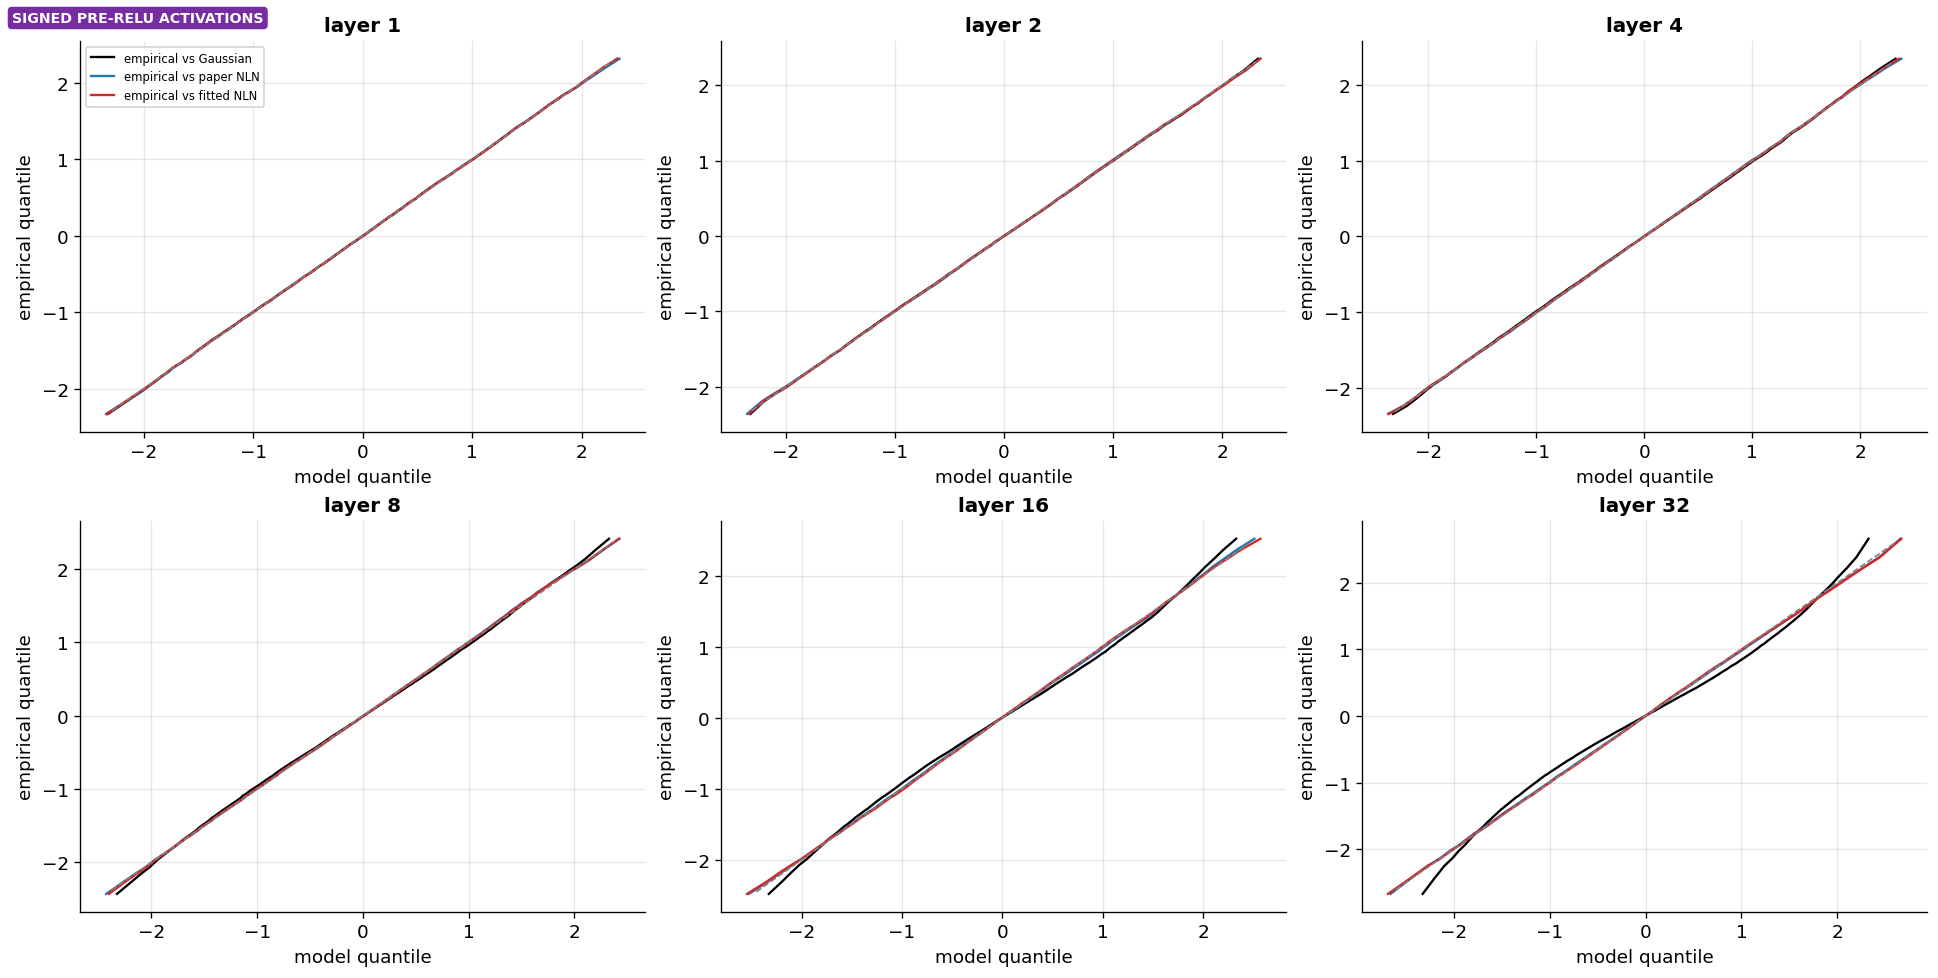

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
qs = np.linspace(0.01, 0.99, 250)

for ax, row, layer_idx in zip(axes.ravel(), summaries, layers_to_check):
    z = standardize(pre_units[:, layer_idx, :])
    empirical_q = np.quantile(z, qs)
    normal_q = stats.norm.ppf(qs)
    paper_q = np.quantile(standardize(normal_lognormal_sample(row["a_paper"])), qs)
    fit_q = np.quantile(standardize(normal_lognormal_sample(row["a_fit"])), qs)
    ax.plot(normal_q, empirical_q, color="black", lw=1.4, label="empirical vs Gaussian")
    ax.plot(paper_q, empirical_q, color="#1f77b4", lw=1.4, label="empirical vs paper NLN")
    ax.plot(fit_q, empirical_q, color="#d62728", lw=1.4, label="empirical vs fitted NLN")
    lim = np.quantile(np.abs(empirical_q), 0.995)
    ax.plot([-lim, lim], [-lim, lim], "--", color="gray", lw=1)
    ax.set(title=f"layer {layer_idx + 1}", xlabel="model quantile", ylabel="empirical quantile")

axes[0, 0].legend(fontsize=7)
badge(fig, "SIGNED PRE-RELU ACTIVATIONS", "#6a1b9a")
plt.show()

## 4. Is plain lognormal better for positive, nonzero activations?

Plain lognormal has positive support, so it should not be used for signed pre-ReLU values. It can be a reasonable model for either $|g^{(ll)}|$ or for the positive post-ReLU slab after removing zeros. The next cell fits a lognormal to the positive post-ReLU slab and reports the zero fraction separately.

In [6]:
def positive_slab_lognormal_summary(layer_idx):
    h = post_units[:, layer_idx, :].ravel().astype(np.float64)
    positive = h[h > 0]
    zero_frac = 1 - positive.size / h.size
    shape, loc, scale = stats.lognorm.fit(positive, floc=0)
    ks = stats.kstest(positive, "lognorm", args=(shape, loc, scale)).statistic
    log_positive = np.log(positive)
    normality_ks = stats.kstest(
        (log_positive - log_positive.mean()) / log_positive.std(ddof=1),
        "norm",
    ).statistic
    return zero_frac, shape, scale, ks, normality_ks


print("ell  zero_frac  lognorm_shape  lognorm_scale  KS positive slab  KS log-values-vs-normal")
slab_rows = []
for layer_idx in layers_to_check:
    row = positive_slab_lognormal_summary(layer_idx)
    slab_rows.append(row)
    print(f"{layer_idx + 1:>3}  {row[0]:>9.1%}  {row[1]:>13.3f}  {row[2]:>13.3f}  {row[3]:>16.3f}  {row[4]:>23.3f}")

ell  zero_frac  lognorm_shape  lognorm_scale  KS positive slab  KS log-values-vs-normal
  1      50.5%          1.093          0.752             0.099                    0.099
  2      49.9%          1.126          0.727             0.100                    0.100
  4      49.9%          1.124          0.719             0.093                    0.093
  8      50.2%          1.131          0.717             0.093                    0.093
 16      49.5%          1.149          0.655             0.089                    0.089
 32      50.2%          1.178          0.606             0.081                    0.081


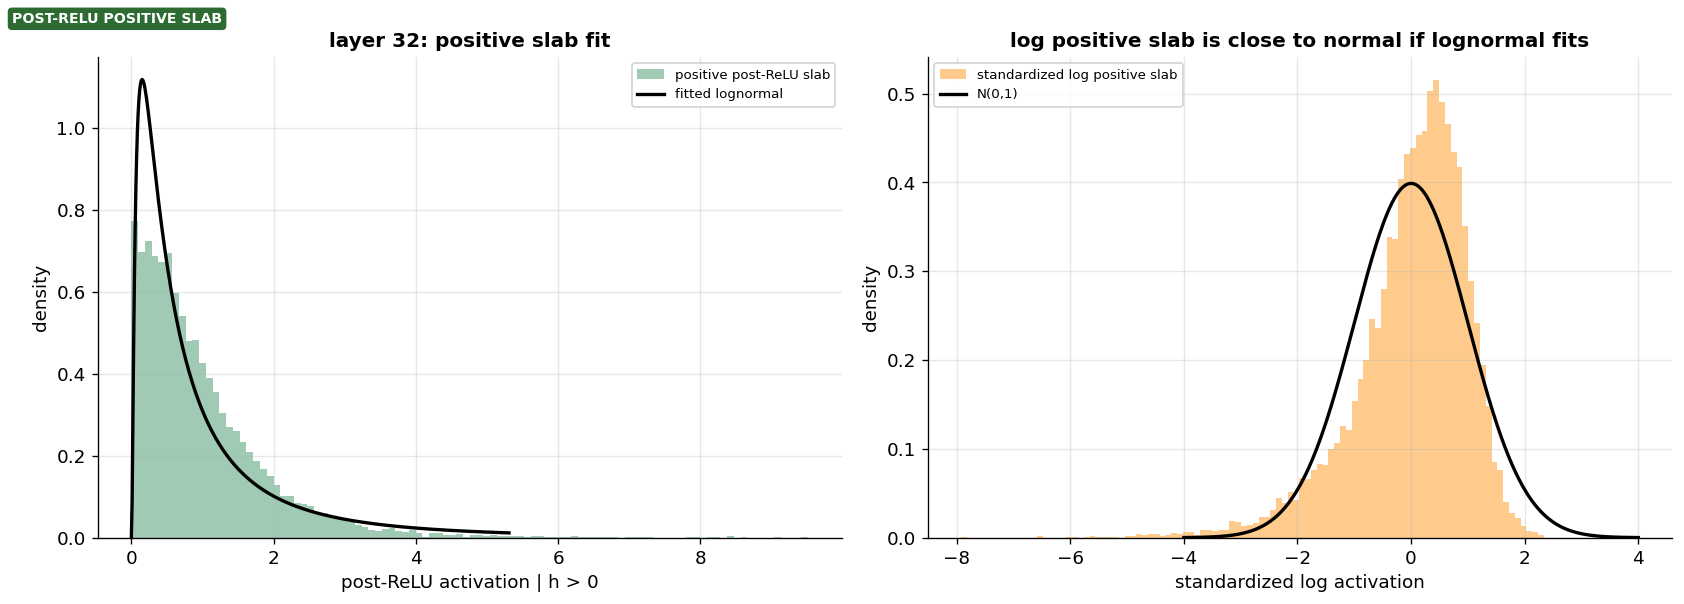

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
selected_layer = 31
h = post_units[:, selected_layer, :].ravel().astype(np.float64)
positive = h[h > 0]
shape, loc, scale = stats.lognorm.fit(positive, floc=0)

axes[0].hist(positive, bins=100, density=True, alpha=0.45, color="seagreen", label="positive post-ReLU slab")
x_grid = np.linspace(0, np.quantile(positive, 0.995), 500)
axes[0].plot(x_grid, stats.lognorm.pdf(x_grid, shape, loc=loc, scale=scale), color="black", lw=2, label="fitted lognormal")
axes[0].set(title=f"layer {selected_layer + 1}: positive slab fit", xlabel="post-ReLU activation | h > 0", ylabel="density")
axes[0].legend(fontsize=8)

log_positive = np.log(positive)
axes[1].hist((log_positive - log_positive.mean()) / log_positive.std(ddof=1), bins=100, density=True, alpha=0.45, color="darkorange", label="standardized log positive slab")
z_grid = np.linspace(-4, 4, 500)
axes[1].plot(z_grid, stats.norm.pdf(z_grid), color="black", lw=2, label="N(0,1)")
axes[1].set(title="log positive slab is close to normal if lognormal fits", xlabel="standardized log activation", ylabel="density")
axes[1].legend(fontsize=8)

plt.tight_layout()
badge(fig, "POST-RELU POSITIVE SLAB", "#1b5e20")
plt.show()

## 5. Conclusions from this WHest run

The evidence supports the impression, with an important support distinction:

- **Signed, untruncated pre-ReLU activations** are much better described by a normal-lognormal scale mixture than by a plain Gaussian once depth is moderate/deep. The empirical kurtosis rises from about 3 at layer 1 to **6.15** at layer 32.
- **The paper's parameter is already close.** At layer 32, the paper-style $a=5\ell/(4m)$ gives `a_paper=0.156`, while the moment-fitted value is `a_fit=0.179`. That is close enough to say the paper's width/depth scaling is capturing the right effect in WHest.
- **Tail fit improves dramatically.** At layer 32, the Gaussian tail quantile error is **0.150**, while paper normal-lognormal is **0.021** and fitted normal-lognormal is **0.015**. KS distance also drops from **0.043** for Gaussian to roughly **0.005-0.007** for normal-lognormal.
- **Plain lognormal is for the positive slab, not the signed activation.** Post-ReLU activations have about **50% exact zeros** at every checked layer, so the full post-ReLU distribution is not lognormal. A lognormal is a reasonable model only after conditioning on `h > 0`; the positive-slab KS improves from about **0.099** at layer 1 to **0.081** at layer 32.
- **WHest target means are one step removed.** `all_layer_means` are expectations over the input distribution, so they are smoother than the single-input prior predictive activations studied by the paper. The paper's normal-lognormal mechanism is still relevant, but most directly for pre-ReLU single-input activations and for explaining why deep ReLU networks create heavy-tailed positive slabs after truncation.